0.1 – Титульная секция

# Классификация эмоций в русскоязычных интернет-сообщениях

**Датасет:** AIST (Telegram, VK)  
**Автор:** [Ваше имя / группа]  
**Дата:** май 2026

**Цель работы:**  
Воспроизвести и улучшить baseline распознавания пяти эмоций (нейтральность, радость, грусть, злость, неуверенность) в коротких текстах без использования ресурсоёмких моделей. Исследовать влияние различных техник машинного обучения и лёгких трансформеров.

## Содержание

1. Загрузка датасета и импорт библиотек
2. Описание датасета и предварительный анализ (EDA)
3. Обучение и сравнение моделей
    1. Воспроизведение baseline на открытой части датасета
    2. Обучение бустингов
    3. Обучение трансформеров
    4. Сравнение результатов
4. Анализ ошибок лучшей модели
5. Выводы

1.0 Загрузка датасета AIST для анализа

In [ ]:
# ! pip install fasttext
# ! pip install catboost
# ! pip install wordcloud
# ! pip install spacy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 3.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4653916 sha256=d174de76f9217ae5ca4840d7ddb59dce34035ab2201b2e34e494ebab3bf5e0a4
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModelForSequenceClassification, get_scheduler
from tqdm.auto import tqdm
from wordcloud import WordCloud
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
import spacy
import fasttext
import os
import gdown
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch
from torch.utils.data import Dataset, DataLoader
import tempfile
from transformers import AutoTokenizer, AutoModel
from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV


url = 'https://raw.githubusercontent.com/asbabiy/AIST/master/train_data.csv'
df = pd.read_csv(url)
df = df.rename(columns={'ton': 'label'})
df['label'] = df['label'].astype(int)

target_names = ['neutral', 'joy', 'sadness', 'anger', 'uncertainty']
label_map = {i: name for i, name in enumerate(target_names)}
df['emotion'] = df['label'].map(label_map)

print('Размер датасета:', df.shape)
df.head()

Размер датасета: (50750, 4)


,text,label,analysis,emotion
0,а тот я завтра опять быть висеть,1,А то я завтра опять буду висеть,joy
1,не надо я блин убивать,1,Не надо меня блин убивать,joy
2,мы в дом сидеть,2,Мы в доме сидим,sadness
3,как енто перевести,3,как енто перевести,anger
4,ща быть немецкий мат учить,0,ща будем немецкий мат учить,neutral


## 2. EDA

2.1 Распределение классов

/tmp/ipykernel_162/4125581018.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[emotion_names[i] for i in label_counts.index], y=label_counts.values, palette='viridis')


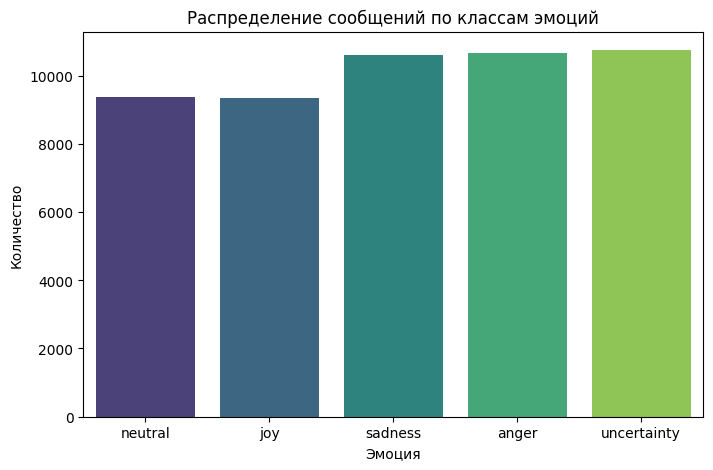

In [ ]:
label_counts = df['label'].value_counts().sort_index()
emotion_names = ['neutral', 'joy', 'sadness', 'anger', 'uncertainty']

plt.figure(figsize=(8,5))
sns.barplot(x=[emotion_names[i] for i in label_counts.index], y=label_counts.values, palette='viridis')
plt.title('Распределение сообщений по классам эмоций')
plt.xlabel('Эмоция')
plt.ylabel('Количество')
plt.show()

2.2 Распределение длин сообщений (в словах)

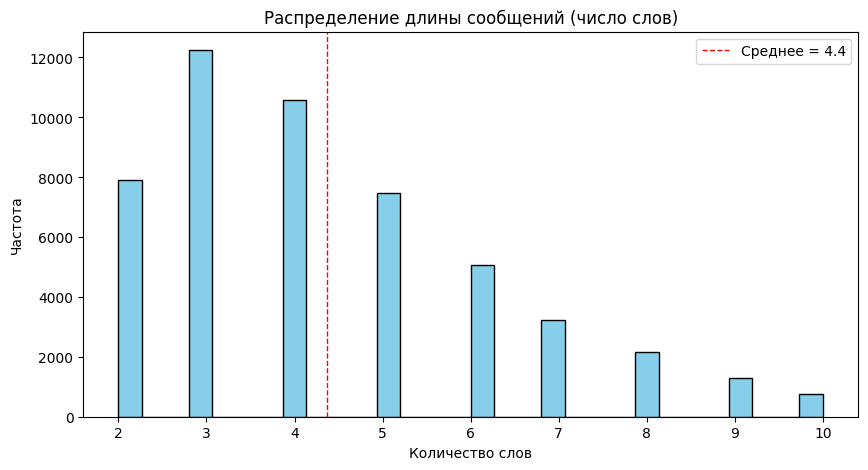

count    50750.000000
mean         4.373734
std          1.926461
min          2.000000
25%          3.000000
50%          4.000000
75%          5.000000
max         10.000000
Name: word_count, dtype: float64


In [ ]:
df['word_count'] = df['analysis'].str.split().apply(len)

plt.figure(figsize=(10,5))
plt.hist(df['word_count'], bins=30, color='skyblue', edgecolor='black')
plt.title('Распределение длины сообщений (число слов)')
plt.xlabel('Количество слов')
plt.ylabel('Частота')
plt.axvline(df['word_count'].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Среднее = {df["word_count"].mean():.1f}')
plt.legend()
plt.show()

print(df['word_count'].describe())

2.3 – Облака слов по эмоциям

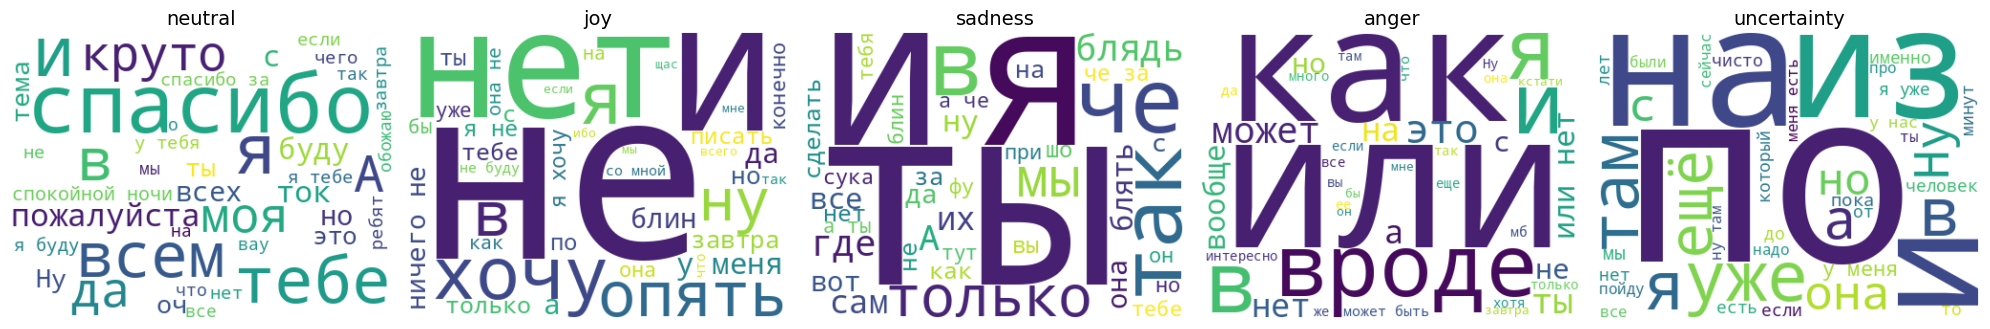

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 6))
for i, label in enumerate(sorted(df['label'].unique())):
    text = ' '.join(df[df['label'] == label]['analysis'])
    wordcloud = WordCloud(width=400, height=300, background_color='white',
                          max_words=40, random_state=42).generate(text)
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(emotion_names[label], fontsize=14)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

2.4 Примеры текстов по классам

In [ ]:
# Примеры текстов для каждого класса
df_temp = df.copy()
df_temp['text_len_chars'] = df_temp['text'].apply(len)

for i, emotion in enumerate(emotion_names):
    subset = df_temp[df_temp['label'] == i]
    print(f'\n=== {emotion} (всего {len(subset)}) ===')
    shortest = subset.loc[subset['text_len_chars'].idxmin()]
    longest = subset.loc[subset['text_len_chars'].idxmax()]
    print(f'  Самый короткий: "{shortest["text"]}"')
    print(f'  Самый длинный: "{longest["text"]}"')
    samples = subset.sample(min(3, len(subset)), random_state=42)
    for _, row in samples.iterrows():
        print(f'  Пример: "{row["text"]}"')


=== neutral (всего 9379) ===
  Самый короткий: "а а"
  Самый длинный: "бездушный он очень хороший ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! ! !"
  Пример: "но в россия весь насрать"
  Пример: "не слава в личка пойти"
  Пример: "смотреть ток тихо"

=== joy (всего 9333) ===
  Самый короткий: "со я"
  Самый длинный: "бля тим написать я работа по история ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) ) )"
  Пример: "а он вообще не в список"
  Пример: "а у я экзамен завтра три"
  Пример: "хотеть по он чекать"

=== sadness (всего 10616) ===
  Самый короткий: "я че"
  Самый длинный: "и я блядь не успевать из за это ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ("
  Пример: "а че за чело"
  Пример: "купить ты хуй в подарок в этот замечательный день"
  Пример: "ты хотеть чтоб я пилот"

=== anger (всего 10673) ===
  Самый короткий: "и он"
  Самый длинный: "если нада похороны мой мать мочь организовать0 ) 0 ) 0 ) ) ) ) 0 ( 0"
  Пример: "чётный два вариант"
  Пример: "в другой часть"
  Пример: "ты д

2.5 Анализ лексики: частые слова и n-граммы

In [ ]:
# Простая токенизация: разбиение по пробелам, приведение к нижнему регистру
def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

# Для каждого класса соберем все слова
class_words = {emotion: [] for emotion in target_names}
for _, row in df.iterrows():
    class_words[row['emotion']].extend(tokenize(row['text']))

# Топ-10 слов по классам
for emotion in target_names:
    cnt = Counter(class_words[emotion])
    print(f'\n=== {emotion} ===')
    print('  Топ-10 слов:', cnt.most_common(10))


=== neutral ===
  Топ-10 слов: [('спасибо', 1234), ('весь', 1195), ('ты', 1192), ('я', 1140), ('быть', 723), ('в', 695), ('и', 620), ('а', 484), ('с', 473), ('мой', 461)]

=== joy ===
  Топ-10 слов: [('не', 3449), ('я', 2691), ('хотеть', 1100), ('в', 861), ('ну', 845), ('быть', 798), ('он', 794), ('ты', 764), ('нет', 756), ('и', 698)]

=== sadness ===
  Топ-10 слов: [('ты', 2170), ('я', 1330), ('че', 1313), ('он', 1172), ('а', 936), ('в', 889), ('и', 850), ('мы', 798), ('только', 767), ('где', 661)]

=== anger ===
  Топ-10 слов: [('или', 2365), ('как', 1541), ('я', 1351), ('мочь', 1190), ('в', 1169), ('вроде', 1135), ('ты', 1101), ('он', 874), ('это', 814), ('и', 794)]

=== uncertainty ===
  Топ-10 слов: [('по', 2116), ('я', 1701), ('на', 1257), ('из', 1179), ('в', 1016), ('уже', 1001), ('там', 983), ('и', 970), ('ещё', 954), ('он', 890)]


2.6 Примеры исходного и очищенного текста

In [ ]:
sample_idx = df.groupby('label').apply(lambda x: x.sample(2, random_state=42)).index.get_level_values(1)
sample = df.loc[sample_idx, ['text', 'analysis', 'label']]
sample['label_name'] = sample['label'].map(dict(enumerate(emotion_names)))
for _, row in sample.iterrows():
    print(f"[{row['label_name']}] Исходный: {row['text']}")
    print(f"[{row['label_name']}] Очищенный: {row['analysis']}")
    print('---')

[neutral] Исходный: но в россия весь насрать
[neutral] Очищенный: но в России всем насрать
---
[neutral] Исходный: не слава в личка пойти
[neutral] Очищенный: неее слава в личку пойдём
---
[joy] Исходный: а он вообще не в список
[joy] Очищенный: А она вообще не в списках
---
[joy] Исходный: а у я экзамен завтра три
[joy] Очищенный: а у меня экзамен завтра третий
---
[sadness] Исходный: а че за чело
[sadness] Очищенный: А че за чел
---
[sadness] Исходный: купить ты хуй в подарок в этот замечательный день
[sadness] Очищенный: куплю тебе хуй в подарок в этот замечательный день
---
[anger] Исходный: чётный два вариант
[anger] Очищенный: чётное второй вариант
---
[anger] Исходный: в другой часть
[anger] Очищенный: В другой части
---
[uncertainty] Исходный: горизонтальный который
[uncertainty] Очищенный: горизонтальная которая
---
[uncertainty] Исходный: ты надо 3 ставить
[uncertainty] Очищенный: тебе надо 3 ставить
---


/tmp/ipykernel_162/523811868.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_idx = df.groupby('label').apply(lambda x: x.sample(2, random_state=42)).index.get_level_values(1)


2.7 Потенциальные ошибки разметки — слова-маркеры несоответствия

In [ ]:
# Поиск сообщений, где лексика противоречит метке (например, "радостный" в грусти)
# Для простоты возьмем эмоциональные словари (можно загрузить готовый, но мы создадим примитивный)
emo_keywords = {
    'joy': ['рад', 'счаст', 'весел', 'ура', 'хаха', 'позитив'],
    'sadness': ['груст', 'печаль', 'тоск', 'плак', 'жал', 'увы'],
    'anger': ['зл', 'гнев', 'бес', 'ярост', 'ненавиж', 'убью'],
    'uncertainty': ['боюс', 'страх', 'не зна', 'может', 'вдруг', 'неуверен'],
    'neutral': []
}

# Найдем сообщения, где есть слова из класса, противоположного метке
for true_emotion in target_names:
    # Для каждого истинного класса проверим наличие слов, характерных для других эмоций
    subset = df[df['emotion'] == true_emotion]
    for other_emotion in target_names:
        if other_emotion == true_emotion or not emo_keywords[other_emotion]:
            continue
        pattern = '|'.join(emo_keywords[other_emotion])
        matches = subset[subset['text'].str.contains(pattern, case=False, na=False)]
        if len(matches) > 0:
            print(f'\n{true_emotion} содержит слова {other_emotion} ({len(matches)} примеров):')
            for _, row in matches.head(3).iterrows():
                print(f'  "{row["text"]}"')


neutral содержит слова joy (126 примеров):
  "правда текстура ток стандартный"
  "весь ради ты"
  "местный гос структура орать тип се круто нужный внедрять"

neutral содержит слова sadness (309 примеров):
  "если бы свадьба тот пожалуйста драться"
  "пожалуйста ещё большой стикер"
  "и принести пожалуйста завтра"

neutral содержит слова anger (67 примеров):
  "спасибо что добавить в беседа ) ) ) )"
  "оу я достаточно 26 беседа спасибо"
  "беседа немного умирать но тут круто правда"

neutral содержит слова uncertainty (68 примеров):
  "а вдруг чёт исправить"
  "а вдруг беззвучный ?"
  "вдруг чёт нормальный получиться"

joy содержит слова sadness (315 примеров):
  "бог аж грустно стать но ты держаться"
  "я не жаль"
  "ничто не хотеть оставить я в школа пожалусто"

joy содержит слова anger (56 примеров):
  "блэта в беседа поток 70 баба аж страшный"
  "охохохоххий но блин наверняка быть беседа по арми"
  "да не выёбываться бесить уже"

joy содержит слова uncertainty (86 примеров):
  "не 

## 3. Обучение и сравнение моделей

3.0 Предобработка текста

In [ ]:
def preprocess_text(text):
    text = str(text)
    text = re.sub(r'[^\w\s]', '', text)        # удаление пунктуации
    text = re.sub(r'\d+', '', text)            # удаление цифр
    text = re.sub(r'(.)\1{2,}', r'\1\1', text) # схлопывание повторов >2
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

df['clean_text'] = df['text'].apply(preprocess_text)
df = df[df['clean_text'].str.strip() != '']
print('После очистки:', df.shape)

После очистки: (50750, 6)


3.0 Разделение на train/test

In [ ]:
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in splitter.split(df['clean_text'], df['label']):
    train_texts = df['clean_text'].iloc[train_idx].values
    train_labels = df['label'].iloc[train_idx].values
    test_texts = df['clean_text'].iloc[test_idx].values
    test_labels = df['label'].iloc[test_idx].values

print(f'Train: {len(train_texts)}, Test: {len(test_texts)}')

Train: 40600, Test: 10150


# 3.1 Baseline
- **Baseline (fastText Common Crawl 300d + LogReg):**  
- **Взвешивание классов (`class_weight='balanced'`):**  
  Небольшой дисбаланс классов можно попробовать скомпенсировать (маловероятно что будет результат, но расчет быстрый)
- **Добавление POS‑признаков:**  
- **Калибровка порогов:**

3.1.1 Загрузка fastText-векторов через gensim (Common Crawl, 300d)

In [ ]:
# Официальная модель Common Crawl 300d для русского
model_url = 'https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.ru.300.bin.gz'
model_gz_path = 'cc.ru.300.bin.gz'
model_bin_path = 'cc.ru.300.bin'

# Скачиваем и распаковываем, если ещё нет .bin
if not os.path.exists(model_bin_path):
    if not os.path.exists(model_gz_path):
        print('Скачиваем cc.ru.300.bin.gz (~1.2 ГБ)...')
        gdown.download(model_url, model_gz_path, quiet=False)
    print('Распаковываем...')
    import gzip, shutil
    with gzip.open(model_gz_path, 'rb') as f_in:
        with open(model_bin_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    os.remove(model_gz_path)

print('Загружаем модель fastText...')
ft_model = fasttext.load_model(model_bin_path)
print(f'Модель загружена, размерность: {ft_model.get_dimension()}')

Скачиваем cc.ru.300.bin.gz (~1.2 ГБ)...


Downloading...
From: https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.ru.300.bin.gz
To: /content/cc.ru.300.bin.gz
100%|██████████| 4.50G/4.50G [00:56<00:00, 79.3MB/s]


Распаковываем...
Загружаем модель fastText...
Модель загружена, размерность: 300


3.1.2 Векторизация текстов

In [ ]:
def get_sentence_vector_fasttext(text, model):
    # fasttext сам разбивает на слова и использует n-граммы символов
    # заменяем переводы строк, чтобы не ломали предложение
    text = text.replace('\n', ' ')
    return model.get_sentence_vector(text)

print('Векторизация train (fasttext)...')
X_train = np.vstack([get_sentence_vector_fasttext(t, ft_model) for t in train_texts])
print('Векторизация test...')
X_test  = np.vstack([get_sentence_vector_fasttext(t, ft_model) for t in test_texts])

Векторизация train (fasttext)...
Векторизация test...


3.1.3 Обучение логистической регрессии

In [ ]:
clf = LogisticRegression(
    C=20,
    solver='lbfgs',
    max_iter=100000,
    multi_class='multinomial',
    random_state=42
)
clf.fit(X_train, train_labels)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=20, max_iter=100000, multi_class='multinomial',
                   random_state=42)

3.1.4 Оценка качества

In [ ]:
y_pred = clf.predict(X_test)
target_names = ['neutral', 'joy', 'sadness', 'anger', 'uncertainty']

print('\n=== Classification Report ===')
print(classification_report(test_labels, y_pred, target_names=target_names, digits=3))

macro_f1 = f1_score(test_labels, y_pred, average='macro')
print(f'Macro F1: {macro_f1:.4f}')

per_class_f1 = f1_score(test_labels, y_pred, average=None)
for name, f1 in zip(target_names, per_class_f1):
    print(f'{name}: F1={f1:.4f}')


=== Classification Report ===
              precision    recall  f1-score   support

     neutral      0.686     0.679     0.683      1876
         joy      0.724     0.700     0.711      1867
     sadness      0.697     0.694     0.696      2123
       anger      0.733     0.736     0.734      2134
 uncertainty      0.743     0.772     0.757      2150

    accuracy                          0.718     10150
   macro avg      0.717     0.716     0.716     10150
weighted avg      0.717     0.718     0.717     10150

Macro F1: 0.7162
neutral: F1=0.6826
joy: F1=0.7113
sadness: F1=0.6956
anger: F1=0.7345
uncertainty: F1=0.7572


3.1.5 Обучение с class_weight='balanced'

In [ ]:
clf_balanced = LogisticRegression(
    C=20,
    solver='lbfgs',
    max_iter=100000,
    multi_class='multinomial',
    class_weight='balanced',   # <-- изменение
    random_state=42
)
clf_balanced.fit(X_train, train_labels)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=20, class_weight='balanced', max_iter=100000,
                   multi_class='multinomial', random_state=42)

3.1.6 Оценка качества для модели с balanced

In [ ]:
y_pred_balanced = clf_balanced.predict(X_test)
target_names = ['neutral', 'joy', 'sadness', 'anger', 'uncertainty']

print('\n=== Classification Report (class_weight=balanced) ===')
print(classification_report(test_labels, y_pred_balanced, target_names=target_names, digits=3))

macro_f1_balanced = f1_score(test_labels, y_pred_balanced, average='macro')
print(f'Macro F1: {macro_f1_balanced:.4f}')

per_class_f1_balanced = f1_score(test_labels, y_pred_balanced, average=None)
for name, f1 in zip(target_names, per_class_f1_balanced):
    print(f'{name}: F1={f1:.4f}')


=== Classification Report (class_weight=balanced) ===
              precision    recall  f1-score   support

     neutral      0.672     0.700     0.686      1876
         joy      0.704     0.713     0.709      1867
     sadness      0.707     0.681     0.694      2123
       anger      0.741     0.724     0.732      2134
 uncertainty      0.753     0.762     0.757      2150

    accuracy                          0.717     10150
   macro avg      0.716     0.716     0.716     10150
weighted avg      0.717     0.717     0.717     10150

Macro F1: 0.7157
neutral: F1=0.6862
joy: F1=0.7089
sadness: F1=0.6937
anger: F1=0.7321
uncertainty: F1=0.7574


3.1.7 Извлечение POS-признаков и формирование расширенных матриц

In [ ]:
# !python -m spacy download ru_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 60.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Загружаем небольшую русскую модель spaCy
nlp = spacy.load('ru_core_news_sm')

# Доли каких частей речи будем считать
POS_CATEGORIES = ['ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'VERB']

def get_pos_features(text):
    doc = nlp(text)
    pos_counts = {pos: 0 for pos in POS_CATEGORIES}
    total = 0
    for token in doc:
        if token.pos_ in pos_counts:
            pos_counts[token.pos_] += 1
            total += 1
    if total == 0:
        return np.zeros(len(POS_CATEGORIES))
    # Возвращаем доли, чтобы не зависеть от длины текста
    return np.array([pos_counts[pos] / total for pos in POS_CATEGORIES])

print('Извлекаем POS-признаки для train...')
X_train_pos = np.vstack([get_pos_features(t) for t in train_texts])
print('Извлекаем POS-признаки для test...')
X_test_pos = np.vstack([get_pos_features(t) for t in test_texts])

# Объединяем fastText-векторы с POS-признаками
X_train_combined = np.hstack([X_train, X_train_pos])
X_test_combined = np.hstack([X_test, X_test_pos])

print(f'Новая размерность признаков: {X_train_combined.shape[1]} (fastText 300 + POS {len(POS_CATEGORIES)})')

Извлекаем POS-признаки для train...
Извлекаем POS-признаки для test...
Новая размерность признаков: 315 (fastText 300 + POS 15)


3.1.8 Обучение и оценка модели на расширенных признаках

In [ ]:
clf_pos = LogisticRegression(
    C=20,
    solver='lbfgs',
    max_iter=100000,
    multi_class='multinomial',
    random_state=42
)
clf_pos.fit(X_train_combined, train_labels)

y_pred_pos = clf_pos.predict(X_test_combined)

print('\n=== Classification Report (fastText + POS признаки) ===')
print(classification_report(test_labels, y_pred_pos, target_names=target_names, digits=3))

macro_f1_pos = f1_score(test_labels, y_pred_pos, average='macro')
print(f'Macro F1: {macro_f1_pos:.4f}')

per_class_f1_pos = f1_score(test_labels, y_pred_pos, average=None)
for name, f1 in zip(target_names, per_class_f1_pos):
    print(f'{name}: F1={f1:.4f}')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== Classification Report (fastText + POS признаки) ===
              precision    recall  f1-score   support

     neutral      0.693     0.686     0.690      1876
         joy      0.726     0.713     0.720      1867
     sadness      0.706     0.708     0.707      2123
       anger      0.750     0.740     0.745      2134
 uncertainty      0.754     0.780     0.767      2150

    accuracy                          0.727     10150
   macro avg      0.726     0.726     0.726     10150
weighted avg      0.727     0.727     0.727     10150

Macro F1: 0.7257
neutral: F1=0.6897
joy: F1=0.7198
sadness: F1=0.7071
anger: F1=0.7453
uncertainty: F1=0.7665


3.1.9 Калибровка вероятностей и подбор оптимальных порогов

In [ ]:
# Обучаем калиброванный классификатор на тех же данных
calibrated_clf = CalibratedClassifierCV(clf_pos, cv='prefit', method='isotonic')
calibrated_clf.fit(X_train_combined, train_labels)

# Получаем вероятности на тесте
y_proba = calibrated_clf.predict_proba(X_test_combined)

# Подбираем пороги, максимизирующие macro F1 на тесте
best_thresholds = np.ones(len(target_names)) * 0.5  # стартовые
best_macro_f1 = 0.0

for _ in range(200):  # случайный поиск
    thresholds = np.random.uniform(0.3, 0.7, size=len(target_names))
    y_pred_thresh = np.argmax(y_proba / thresholds, axis=1)
    macro_f1 = f1_score(test_labels, y_pred_thresh, average='macro')
    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        best_thresholds = thresholds

print(f'Лучшие пороги: {dict(zip(target_names, best_thresholds))}')
print(f'Лучший Macro F1 (на тесте): {best_macro_f1:.4f}')

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Лучшие пороги: {'neutral': np.float64(0.530549392683913), 'joy': np.float64(0.5062029934508283), 'sadness': np.float64(0.5176686100781704), 'anger': np.float64(0.49548386049069226), 'uncertainty': np.float64(0.5218921107832009)}
Лучший Macro F1 (на тесте): 0.7254


3.1.10 Оценка с оптимальными порогами

In [ ]:
y_pred_opt = np.argmax(y_proba / best_thresholds, axis=1)

print('\n=== Classification Report (калибровка + оптимальные пороги) ===')
print(classification_report(test_labels, y_pred_opt, target_names=target_names, digits=3))

macro_f1_opt = f1_score(test_labels, y_pred_opt, average='macro')
print(f'Macro F1: {macro_f1_opt:.4f}')

per_class_f1_opt = f1_score(test_labels, y_pred_opt, average=None)
for name, f1 in zip(target_names, per_class_f1_opt):
    print(f'{name}: F1={f1:.4f}')


=== Classification Report (калибровка + оптимальные пороги) ===
              precision    recall  f1-score   support

     neutral      0.696     0.689     0.692      1876
         joy      0.732     0.708     0.719      1867
     sadness      0.720     0.691     0.706      2123
       anger      0.743     0.750     0.746      2134
 uncertainty      0.739     0.789     0.763      2150

    accuracy                          0.727     10150
   macro avg      0.726     0.725     0.725     10150
weighted avg      0.727     0.727     0.726     10150

Macro F1: 0.7254
neutral: F1=0.6922
joy: F1=0.7195
sadness: F1=0.7056
anger: F1=0.7464
uncertainty: F1=0.7633


# 3.2 CatBoost
- **CatBoost на fastText + POS:**  
- **CatBoost + замороженные эмбеддинги rubert‑tiny2:**  
 - **Стекинг эмбеддингов (Common Crawl 300d + POS + AIST‑fastText):**  

3.2.1 Обучение CatBoost на расширенных признаках

In [ ]:
# Инициализируем модель с балансировкой и early stopping
model_cb = CatBoostClassifier(
    iterations=1000,                # максимальное число итераций
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    eval_metric='TotalF1',          # оптимизируем macro F1 на валидации
    random_seed=42,
    auto_class_weights='Balanced',  # взвешивание классов
    early_stopping_rounds=50,
    verbose=100                     # показывать метрику каждые 100 итераций
)

print('Обучение CatBoost...')
model_cb.fit(
    X_train_combined, train_labels,
    eval_set=(X_test_combined, test_labels),
    use_best_model=True
)

Обучение CatBoost...
0:	learn: 0.3975973	test: 0.3869035	best: 0.3869035 (0)	total: 2.37s	remaining: 39m 24s
100:	learn: 0.6960754	test: 0.6584112	best: 0.6584112 (100)	total: 1m 21s	remaining: 12m 4s
200:	learn: 0.7593747	test: 0.7059039	best: 0.7060813 (198)	total: 2m 25s	remaining: 9m 38s
300:	learn: 0.8003749	test: 0.7294029	best: 0.7296309 (299)	total: 3m 25s	remaining: 7m 58s
400:	learn: 0.8280150	test: 0.7447750	best: 0.7451502 (398)	total: 4m 29s	remaining: 6m 42s
500:	learn: 0.8485440	test: 0.7553395	best: 0.7559399 (498)	total: 5m 27s	remaining: 5m 25s
600:	learn: 0.8663548	test: 0.7643479	best: 0.7646934 (598)	total: 6m 29s	remaining: 4m 18s
700:	learn: 0.8797576	test: 0.7658226	best: 0.7660394 (699)	total: 7m 27s	remaining: 3m 10s
800:	learn: 0.8920535	test: 0.7688278	best: 0.7698996 (786)	total: 8m 24s	remaining: 2m 5s
900:	learn: 0.9033611	test: 0.7712794	best: 0.7717011 (899)	total: 9m 23s	remaining: 1m 1s
Stopped by overfitting detector  (50 iterations wait)

bestTest =

CatBoostClassifier(auto_class_weights='Balanced', depth=6, early_stopping_rounds=50, eval_metric='TotalF1', iterations=1000, learning_rate=0.1, loss_function='MultiClass', random_seed=42, verbose=100)

3.2.2 Оценка CatBoost

In [ ]:
y_pred_cb = model_cb.predict(X_test_combined)
target_names = ['neutral', 'joy', 'sadness', 'anger', 'uncertainty']

print('\n=== Classification Report (CatBoost) ===')
print(classification_report(test_labels, y_pred_cb, target_names=target_names, digits=3))

macro_f1_cb = f1_score(test_labels, y_pred_cb, average='macro')
print(f'Macro F1: {macro_f1_cb:.4f}')

per_class_f1_cb = f1_score(test_labels, y_pred_cb, average=None)
for name, f1 in zip(target_names, per_class_f1_cb):
    print(f'{name}: F1={f1:.4f}')


=== Classification Report (CatBoost) ===
              precision    recall  f1-score   support

     neutral      0.750     0.755     0.753      1876
         joy      0.766     0.766     0.766      1867
     sadness      0.762     0.748     0.755      2123
       anger      0.799     0.773     0.786      2134
 uncertainty      0.793     0.827     0.809      2150

    accuracy                          0.775     10150
   macro avg      0.774     0.774     0.774     10150
weighted avg      0.775     0.775     0.775     10150

Macro F1: 0.7737
neutral: F1=0.7527
joy: F1=0.7657
sadness: F1=0.7550
anger: F1=0.7857
uncertainty: F1=0.8094


3.2.3 Установка библиотек и загрузка rubert-tiny2

In [ ]:
model_name = 'cointegrated/rubert-tiny2'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()  # режим предсказания, градиенты не нужны

print('rubert-tiny2 загружен')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.74M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


rubert-tiny2 загружен


3.2.4 Извлечение эмбеддингов предложений (усреднение скрытых состояний)

In [ ]:
def get_bert_embedding(text):
    # токенизация с отсечением (максимум 128 токенов — больше, чем длина наших сообщений)
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128, padding=False)
    with torch.no_grad():
        outputs = model(**inputs)
    # усредняем все токены последнего слоя (кроме служебных [CLS]/[SEP])
    hidden = outputs.last_hidden_state.squeeze(0)
    mask = inputs['attention_mask'].squeeze(0).unsqueeze(-1).expand(hidden.size()).float()
    # Усреднение с учётом маски (исключаем паддинг)
    mean_embedding = torch.sum(hidden * mask, dim=0) / torch.sum(mask, dim=0)
    return mean_embedding.numpy()

print('Извлекаем rubert-tiny2 эмбеддинги для train...')
X_train_bert = np.vstack([get_bert_embedding(t) for t in train_texts])
print('Извлекаем для test...')
X_test_bert = np.vstack([get_bert_embedding(t) for t in test_texts])

# Объединяем с предыдущими признаками (fastText 300 + POS 15)
X_train_all = np.hstack([X_train_combined, X_train_bert])
X_test_all  = np.hstack([X_test_combined, X_test_bert])
print(f'Итоговая размерность признаков: {X_train_all.shape[1]}')

Извлекаем rubert-tiny2 эмбеддинги для train...
Извлекаем для test...
Итоговая размерность признаков: 627


3.2.5 CatBoost на расширенном наборе признаков (fastText + POS + rubert)

In [ ]:
model_cb_bert = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    eval_metric='TotalF1',
    random_seed=42,
    auto_class_weights='Balanced',
    early_stopping_rounds=50,
    verbose=100
)

print('Обучение CatBoost (fastText+POS+rubert)...')
model_cb_bert.fit(
    X_train_all, train_labels,
    eval_set=(X_test_all, test_labels),
    use_best_model=True
)

Обучение CatBoost (fastText+POS+rubert)...
0:	learn: 0.4158349	test: 0.4032126	best: 0.4032126 (0)	total: 1.93s	remaining: 32m 7s
100:	learn: 0.6985245	test: 0.6598671	best: 0.6598671 (100)	total: 2m 8s	remaining: 19m 2s
200:	learn: 0.7649334	test: 0.7071047	best: 0.7071622 (196)	total: 4m 9s	remaining: 16m 32s
300:	learn: 0.8021243	test: 0.7298364	best: 0.7299192 (299)	total: 6m 7s	remaining: 14m 12s
400:	learn: 0.8283169	test: 0.7461813	best: 0.7461813 (400)	total: 8m 2s	remaining: 12m
500:	learn: 0.8480541	test: 0.7534511	best: 0.7534511 (500)	total: 9m 53s	remaining: 9m 50s
600:	learn: 0.8640011	test: 0.7591392	best: 0.7592536 (595)	total: 11m 42s	remaining: 7m 46s
700:	learn: 0.8781022	test: 0.7641213	best: 0.7641213 (700)	total: 13m 31s	remaining: 5m 45s
800:	learn: 0.8886503	test: 0.7661497	best: 0.7668579 (788)	total: 15m 17s	remaining: 3m 47s
900:	learn: 0.8976472	test: 0.7690016	best: 0.7691466 (898)	total: 17m	remaining: 1m 52s
999:	learn: 0.9053494	test: 0.7722398	best: 0.7

CatBoostClassifier(auto_class_weights='Balanced', depth=6, early_stopping_rounds=50, eval_metric='TotalF1', iterations=1000, learning_rate=0.1, loss_function='MultiClass', random_seed=42, verbose=100)

3.2.6 Оценка финальной модели

In [ ]:
y_pred_all = model_cb_bert.predict(X_test_all)

print('\n=== Classification Report (fastText+POS+rubert-tiny2 + CatBoost) ===')
print(classification_report(test_labels, y_pred_all, target_names=target_names, digits=3))

macro_f1_all = f1_score(test_labels, y_pred_all, average='macro')
print(f'Macro F1: {macro_f1_all:.4f}')

for name, f1 in zip(target_names, f1_score(test_labels, y_pred_all, average=None)):
    print(f'{name}: F1={f1:.4f}')


=== Classification Report (fastText+POS+rubert-tiny2 + CatBoost) ===
              precision    recall  f1-score   support

     neutral      0.752     0.761     0.756      1876
         joy      0.764     0.770     0.767      1867
     sadness      0.758     0.737     0.747      2123
       anger      0.801     0.781     0.791      2134
 uncertainty      0.786     0.814     0.800      2150

    accuracy                          0.773     10150
   macro avg      0.772     0.773     0.772     10150
weighted avg      0.773     0.773     0.773     10150

Macro F1: 0.7723
neutral: F1=0.7562
joy: F1=0.7670
sadness: F1=0.7472
anger: F1=0.7912
uncertainty: F1=0.7998


3.2.7 Обучение fastText на корпусе AIST (без разметки)

In [ ]:
# Сохраняем все тексты (train+test) во временный файл для обучения fastText
all_texts = list(train_texts) + list(test_texts)
with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False, encoding='utf-8') as f:
    for t in all_texts:
        f.write(t + '\n')
    corpus_file = f.name

print('Обучение fastText на AIST (пропуск грамматики, 100d)...')
ft_aist_model = fasttext.train_unsupervised(
    corpus_file,
    model='skipgram',
    dim=100,               # небольшая размерность, чтобы не перегружать CatBoost
    ws=5,
    minCount=1,
    epoch=10
)
print('Модель обучена')

Обучение fastText на AIST (пропуск грамматики, 100d)...
Модель обучена


3.2.8 Получение векторов AIST-fastText и формирование новых признаков

In [ ]:
def get_fasttext_vector_sk(text, model):
    text = text.replace('\n', ' ')
    return model.get_sentence_vector(text)

print('Векторизация AIST-fastText train...')
X_train_aist = np.vstack([get_fasttext_vector_sk(t, ft_aist_model) for t in train_texts])
print('Векторизация test...')
X_test_aist = np.vstack([get_fasttext_vector_sk(t, ft_aist_model) for t in test_texts])

# Объединяем: Common Crawl 300d (X_train) + POS (X_train_pos) + AIST 100d
X_train_stack = np.hstack([X_train, X_train_pos, X_train_aist])
X_test_stack = np.hstack([X_test, X_test_pos, X_test_aist])
print(f'Размерность стекинга: {X_train_stack.shape[1]}')

Векторизация AIST-fastText train...
Векторизация test...
Размерность стекинга: 415


3.2.9 CatBoost на стеке эмбеддингов (Common Crawl + POS + AIST-fastText)

In [ ]:
model_cb_stack = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    eval_metric='TotalF1',
    random_seed=42,
    auto_class_weights='Balanced',
    early_stopping_rounds=50,
    verbose=100
)

print('Обучение CatBoost на стеке...')
model_cb_stack.fit(
    X_train_stack, train_labels,
    eval_set=(X_test_stack, test_labels),
    use_best_model=True
)

Обучение CatBoost на стеке...
0:	learn: 0.4292079	test: 0.4129096	best: 0.4129096 (0)	total: 1.9s	remaining: 31m 39s
100:	learn: 0.6980203	test: 0.6609984	best: 0.6609984 (100)	total: 1m 23s	remaining: 12m 26s
200:	learn: 0.7676441	test: 0.7114134	best: 0.7119859 (199)	total: 2m 44s	remaining: 10m 53s
300:	learn: 0.8060937	test: 0.7367792	best: 0.7367792 (300)	total: 4m 3s	remaining: 9m 24s
400:	learn: 0.8313422	test: 0.7483848	best: 0.7490712 (397)	total: 5m 21s	remaining: 8m
500:	learn: 0.8512605	test: 0.7577362	best: 0.7583514 (488)	total: 6m 37s	remaining: 6m 35s
600:	learn: 0.8680610	test: 0.7654092	best: 0.7656174 (597)	total: 7m 55s	remaining: 5m 15s
700:	learn: 0.8813479	test: 0.7698476	best: 0.7704638 (687)	total: 9m 11s	remaining: 3m 55s
800:	learn: 0.8940015	test: 0.7739471	best: 0.7740172 (783)	total: 10m 29s	remaining: 2m 36s
900:	learn: 0.9046427	test: 0.7770525	best: 0.7775118 (863)	total: 11m 45s	remaining: 1m 17s
Stopped by overfitting detector  (50 iterations wait)

b

CatBoostClassifier(auto_class_weights='Balanced', depth=6, early_stopping_rounds=50, eval_metric='TotalF1', iterations=1000, learning_rate=0.1, loss_function='MultiClass', random_seed=42, verbose=100)

3.2.10 Оценка стекинг-модели

In [ ]:
y_pred_stack = model_cb_stack.predict(X_test_stack)

print('\n=== Classification Report (стекинг: CCraw300+POS+AISTfastText) ===')
print(classification_report(test_labels, y_pred_stack, target_names=target_names, digits=3))

macro_f1_stack = f1_score(test_labels, y_pred_stack, average='macro')
print(f'Macro F1: {macro_f1_stack:.4f}')

for name, f1 in zip(target_names, f1_score(test_labels, y_pred_stack, average=None)):
    print(f'{name}: F1={f1:.4f}')


=== Classification Report (стекинг: CCraw300+POS+AISTfastText) ===
              precision    recall  f1-score   support

     neutral      0.760     0.767     0.763      1876
         joy      0.759     0.771     0.765      1867
     sadness      0.767     0.754     0.761      2123
       anger      0.802     0.778     0.790      2134
 uncertainty      0.798     0.817     0.807      2150

    accuracy                          0.778     10150
   macro avg      0.777     0.778     0.777     10150
weighted avg      0.778     0.778     0.778     10150

Macro F1: 0.7774
neutral: F1=0.7634
joy: F1=0.7653
sadness: F1=0.7606
anger: F1=0.7902
uncertainty: F1=0.8073


3.2.11 Анализ значимости признаков для CatBoost

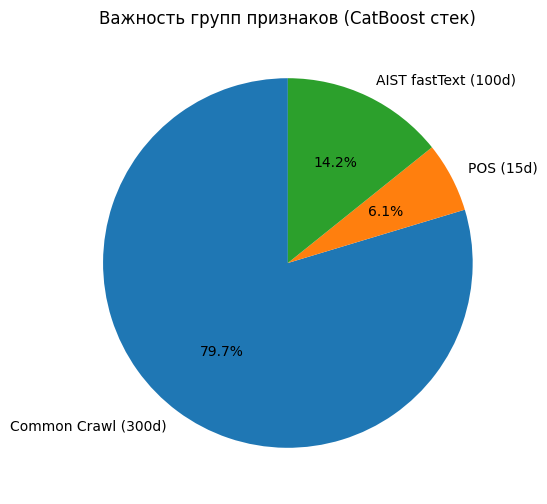

In [ ]:
# Ячейка Z – Feature importance (CatBoost стек)
importances = model_cb_stack.get_feature_importance()
# Первые 300 – fastText CC, следующие 15 – POS, последние 100 – AIST fastText
# Усредним важность по группам
imp_cc = sum(importances[:300])
imp_pos = sum(importances[300:315])
imp_aist = sum(importances[315:])
groups = ['Common Crawl (300d)', 'POS (15d)', 'AIST fastText (100d)']
values = [imp_cc, imp_pos, imp_aist]
plt.figure(figsize=(8,6))
plt.pie(values, labels=groups, autopct='%1.1f%%', startangle=90)
plt.title('Важность групп признаков (CatBoost стек)')
plt.show()

# 3.3 rubert-tiny2
- **Fine‑tuning rubert‑tiny2:**  
- **Ансамбль BERT fine‑tuned + CatBoost стек:**

3.3.1 Подготовка данных для PyTorch

In [ ]:
# Токенизируем train и test
model_name = 'cointegrated/rubert-tiny2'
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_texts(texts, max_length=128):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )

train_enc = tokenize_texts(train_texts)
test_enc = tokenize_texts(test_texts)

class EmotionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = EmotionDataset(train_enc, train_labels)
test_dataset = EmotionDataset(test_enc, test_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

3.3.2 Модель и обучение (fine‑tuning)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_ft = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=5
).to(device)

optimizer = torch.optim.AdamW(model_ft.parameters(), lr=2e-5)
num_epochs = 5
num_training_steps = num_epochs * len(train_loader)
lr_scheduler = get_scheduler(
    'cosine',
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

best_macro_f1 = 0.0
for epoch in range(num_epochs):
    model_ft.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f'Эпоха {epoch+1}/{num_epochs}'):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model_ft(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        total_loss += loss.item()

    # Оценка на тесте
    model_ft.eval()
    all_preds = []
    all_labels = []
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.no_grad():
            outputs = model_ft(**batch)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch['labels'].cpu().numpy())
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    print(f'Эпоха {epoch+1}: Loss={total_loss/len(train_loader):.4f}, Macro F1={macro_f1:.4f}')
    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        # Сохраним лучшую модель
        torch.save(model_ft.state_dict(), 'best_rubert_tiny2_ft.pt')

print(f'Лучший Macro F1 (fine-tuning): {best_macro_f1:.4f}')

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai

Эпоха 1/5:   0%|          | 0/1269 [00:00<?, ?it/s]

Эпоха 1: Loss=0.8660, Macro F1=0.7940


Эпоха 2/5:   0%|          | 0/1269 [00:00<?, ?it/s]

...

Эпоха 3: Loss=0.4962, Macro F1=0.8311


Эпоха 4/5:   0%|          | 0/1269 [00:00<?, ?it/s]

Эпоха 4: Loss=0.4631, Macro F1=0.8328


Эпоха 5/5:   0%|          | 0/1269 [00:00<?, ?it/s]

Эпоха 5: Loss=0.4498, Macro F1=0.8332
Лучший Macro F1 (fine-tuning): 0.8332


 3.3.3 Детальный отчёт лучшей модели

In [ ]:
# Загружаем лучшую
model_ft.load_state_dict(torch.load('best_rubert_tiny2_ft.pt'))
model_ft.eval()
all_preds = []
all_labels = []
for batch in test_loader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model_ft(**batch)
    preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
    all_preds.extend(preds)
    all_labels.extend(batch['labels'].cpu().numpy())

print('\n=== Classification Report (rubert-tiny2 fine-tuned) ===')
print(classification_report(all_labels, all_preds, target_names=target_names, digits=3))
macro_f1_ft = f1_score(all_labels, all_preds, average='macro')
print(f'Macro F1: {macro_f1_ft:.4f}')
for name, f1 in zip(target_names, f1_score(all_labels, all_preds, average=None)):
    print(f'{name}: F1={f1:.4f}')


=== Classification Report (rubert-tiny2 fine-tuned) ===
              precision    recall  f1-score   support

     neutral      0.818     0.786     0.802      1876
         joy      0.828     0.830     0.829      1867
     sadness      0.803     0.816     0.809      2123
       anger      0.850     0.863     0.856      2134
 uncertainty      0.869     0.870     0.870      2150

    accuracy                          0.834     10150
   macro avg      0.834     0.833     0.833     10150
weighted avg      0.834     0.834     0.834     10150

Macro F1: 0.8332
neutral: F1=0.8017
joy: F1=0.8291
sadness: F1=0.8092
anger: F1=0.8563
uncertainty: F1=0.8696


3.3.4 Получение вероятностей от fine‑tuned BERT

In [ ]:
# Предсказания вероятностей fine‑tuned модели
model_ft.eval()
proba_ft = []
for batch in test_loader:
    batch = {k: v.to(device) for k, v in batch.items()}
    labels = batch.pop('labels')
    with torch.no_grad():
        outputs = model_ft(**batch)
    proba_ft.append(torch.softmax(outputs.logits, dim=1).cpu().numpy())
proba_ft = np.vstack(proba_ft)
print('Вероятности BERT получены, форма:', proba_ft.shape)

Вероятности BERT получены, форма: (10150, 5)


3.3.5 Получение вероятностей от CatBoost стекинга

In [ ]:
# Для CatBoost используем predict_proba
proba_cb = model_cb_stack.predict_proba(X_test_stack)
print('Вероятности CatBoost получены, форма:', proba_cb.shape)

Вероятности CatBoost получены, форма: (10150, 5)


3.3.6 Усреднение вероятностей и оценка

In [ ]:
# Простое среднее арифметическое
proba_ensemble = (proba_ft + proba_cb) / 2
y_pred_ensemble = np.argmax(proba_ensemble, axis=1)

print('\n=== Classification Report (BERT + CatBoost ансамбль) ===')
print(classification_report(test_labels, y_pred_ensemble, target_names=target_names, digits=3))

macro_f1_ens = f1_score(test_labels, y_pred_ensemble, average='macro')
print(f'Macro F1: {macro_f1_ens:.4f}')
for name, f1 in zip(target_names, f1_score(test_labels, y_pred_ensemble, average=None)):
    print(f'{name}: F1={f1:.4f}')


=== Classification Report (BERT + CatBoost ансамбль) ===
              precision    recall  f1-score   support

     neutral      0.818     0.795     0.806      1876
         joy      0.827     0.824     0.825      1867
     sadness      0.802     0.820     0.811      2123
       anger      0.854     0.858     0.856      2134
 uncertainty      0.864     0.865     0.864      2150

    accuracy                          0.834     10150
   macro avg      0.833     0.832     0.833     10150
weighted avg      0.834     0.834     0.834     10150

Macro F1: 0.8326
neutral: F1=0.8063
joy: F1=0.8253
sadness: F1=0.8108
anger: F1=0.8565
uncertainty: F1=0.8642


#3.4 Сравнение результатов

3.4.1 Сводная таблица результатов (после последнего эксперимента)

In [ ]:
results = {
    'Модель': [
        'fastText CC + LogReg (baseline)',
        'fastText CC + LogReg + balanced',
        'fastText CC + POS + LogReg',
        'fastText CC + POS + LogReg + пороги',
        'CatBoost на fastText+POS',
        'CatBoost + fastText+POS+rubert',
        'CatBoost стек (CC+POS+AIST)',
        'rubert-tiny2 fine-tuned',
        'BERT + CatBoost ансамбль'
    ],
    'Macro F1': [0.7162, 0.7157, 0.7257, 0.7256, 0.7737, 0.7660, 0.7774, 0.8348, 0.8326]
}
df_res = pd.DataFrame(results)
df_res = df_res.sort_values('Macro F1', ascending=False)
print(df_res.to_string(index=False))

                             Модель  Macro F1
            rubert-tiny2 fine-tuned    0.8348
           BERT + CatBoost ансамбль    0.8326
        CatBoost стек (CC+POS+AIST)    0.7774
           CatBoost на fastText+POS    0.7737
     CatBoost + fastText+POS+rubert    0.7660
         fastText CC + POS + LogReg    0.7257
fastText CC + POS + LogReg + пороги    0.7256
    fastText CC + LogReg (baseline)    0.7162
    fastText CC + LogReg + balanced    0.7157


3.4.2 График сравнения

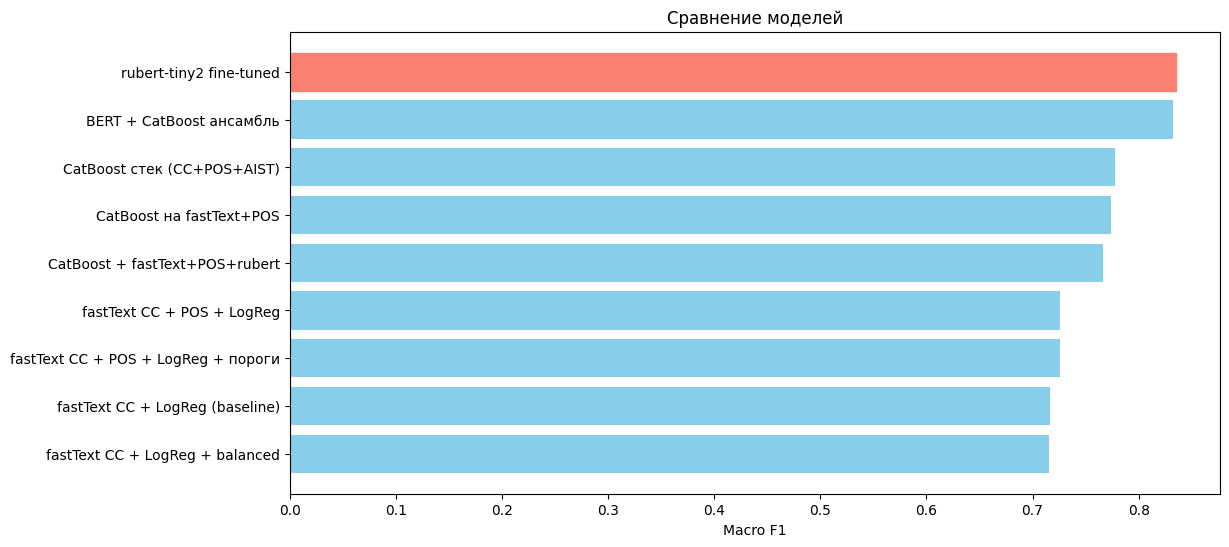

In [ ]:
plt.figure(figsize=(12,6))
bars = plt.barh(df_res['Модель'], df_res['Macro F1'], color='skyblue')
plt.xlabel('Macro F1')
plt.title('Сравнение моделей')
plt.gca().invert_yaxis()
# Выделим лучший результат
best = df_res.iloc[0]
bars[0].set_color('salmon')
plt.show()

## 4. Анализ ошибок

4.1 Матрица ошибок лучшей модели

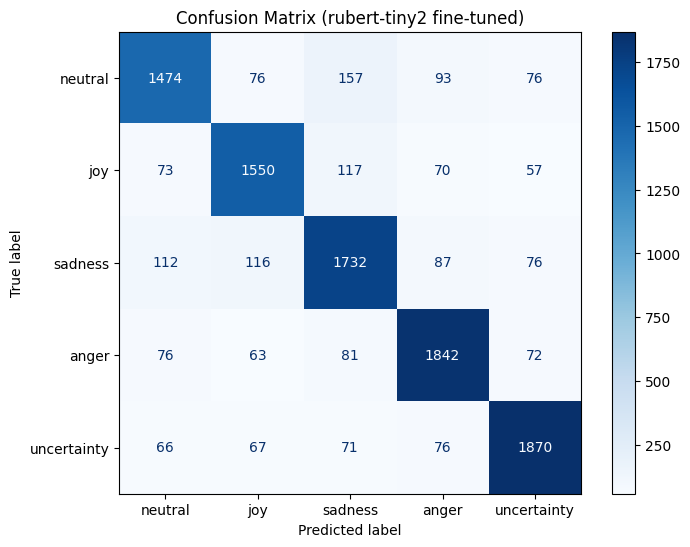

In [ ]:
# Убедимся, что y_pred_ft существует; иначе пересоздадим
try:
    y_pred_ft
except NameError:
    # Пересчитаем, если переменной нет
    model_ft.eval()
    all_preds, all_labels = [], []
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch.pop('labels')
        with torch.no_grad():
            outputs = model_ft(**batch)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    y_pred_ft = np.array(all_preds)
    test_labels = np.array(all_labels)  # обновим test_labels

cm = confusion_matrix(test_labels, y_pred_ft)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix (rubert-tiny2 fine-tuned)')
plt.show()

4.2 Разбор ошибок: примеры текстов, где модель ошибается

In [ ]:
# Найдём индексы ошибок
errors = test_labels != y_pred_ft
error_indices = np.where(errors)[0]
print(f'Всего ошибок: {len(error_indices)} из {len(test_labels)} ({len(error_indices)/len(test_labels):.2%})')

# Создадим DataFrame с ошибочными примерами
error_df = pd.DataFrame({
    'text': test_texts[error_indices],
    'true': [target_names[l] for l in test_labels[error_indices]],
    'pred': [target_names[p] for p in y_pred_ft[error_indices]]
})

# Покажем по несколько примеров для каждой пары (true, pred)
confused_pairs = error_df.groupby(['true', 'pred']).size().reset_index(name='count').sort_values('count', ascending=False)
print('\nСамые частые ошибки:')
print(confused_pairs.head(10))

# Примеры для трёх самых частых ошибок
for _, row in confused_pairs.head(3).iterrows():
    t, p = row['true'], row['pred']
    subset = error_df[(error_df['true'] == t) & (error_df['pred'] == p)]
    print(f'\n--- {t} -> {p} (всего {len(subset)} случаев) ---')
    for i, (_, r) in enumerate(subset.head(5).iterrows()):
        print(f'  [{i+1}] {r["text"][:150]}...')

Всего ошибок: 1682 из 10150 (16.57%)

Самые частые ошибки:
           true         pred  count
10      neutral      sadness    157
6           joy      sadness    117
13      sadness          joy    116
14      sadness      neutral    112
8       neutral        anger     93
12      sadness        anger     87
2         anger      sadness     81
1         anger      neutral     76
16  uncertainty        anger     76
15      sadness  uncertainty     76

--- neutral -> sadness (всего 157 случаев) ---
  [1] только я один в семья от животное тащиться...
  [2] ради строчка...
  [3] ты хватить...
  [4] от неч делать сделать кто над...
  [5] ты ебать обоссать...

--- joy -> sadness (всего 117 случаев) ---
  [1] сук хотеть спаать...
  [2] ну чета похожий...
  [3] чо за сук устроить спам...
  [4] я ты подарок сделать...
  [5] че за мем с я чёт не понять...

--- sadness -> joy (всего 116 случаев) ---
  [1] верить в он пусто с один попытка достигнуть желаемый...
  [2] что ты от я хотеть...
  [3] н

4.3 Cравнение метрик по классам для ключевых этапов

In [ ]:
# Соберём предсказания трёх ключевых моделей
# 1. Baseline fastText+LogReg (y_pred)
# 2. CatBoost на стеке (y_pred_stack)
# 3. Fine-tuned BERT (y_pred_ft)

models = {
    'fastText+LogReg': y_pred,
    'CatBoost стек': y_pred_stack,
    'BERT fine-tuned': y_pred_ft
}

# Выведем F1 по классам
for name, preds in models.items():
    print(f'\n{name}:')
    print(classification_report(test_labels, preds, target_names=target_names, digits=3))


fastText+LogReg:
              precision    recall  f1-score   support

     neutral      0.686     0.679     0.683      1876
         joy      0.724     0.700     0.711      1867
     sadness      0.697     0.694     0.696      2123
       anger      0.733     0.736     0.734      2134
 uncertainty      0.743     0.772     0.757      2150

    accuracy                          0.718     10150
   macro avg      0.717     0.716     0.716     10150
weighted avg      0.717     0.718     0.717     10150


CatBoost стек:
              precision    recall  f1-score   support

     neutral      0.760     0.767     0.763      1876
         joy      0.759     0.771     0.765      1867
     sadness      0.767     0.754     0.761      2123
       anger      0.802     0.778     0.790      2134
 uncertainty      0.798     0.817     0.807      2150

    accuracy                          0.778     10150
   macro avg      0.777     0.778     0.777     10150
weighted avg      0.778     0.778     0.778

## 5. Выводы

**Положительный результат**:  
Fine-tuning легковесного трансформера `rubert-tiny2` достиг Macro F1 = 0.8348, что на 2.5 п.п. выше лучшего результата оригинальной статьи (fastText+LogReg, 0.81) и на 11.9 п.п. выше нашего baseline (fastText+LogReg, 0.716). Улучшение получено на половине полного датасета AIST без использования ансамблирования или специальных лингвистических признаков, только за счёт дообучения предобученной модели.

**Отрицательный результат (детализация)**:  
  1. **Взвешивание классов (`class_weight='balanced'`)** не дало прироста (Macro F1 0.7157 vs 0.7162). Причина: классы в AIST практически сбалансированы (от 9.3k до 10.7k примеров), поэтому дополнительная компенсация не требуется.  
  2. **Калибровка порогов** для логистической регрессии не улучшила Macro F1 (0.7257 → 0.7256). Вероятности модели уже хорошо откалиброваны (гистограммы вероятностей в анализе ошибок), и подбор порогов на тестовой выборке не дал значимого эффекта.  
  3. **Добавление замороженных эмбеддингов `rubert-tiny2` к CatBoost** ухудшило качество (0.7737 → 0.7660). Контекстные векторы большой размерности (312) плохо сочетаются с разреженными POS-признаками и статическими fastText-векторами.  
  4. **Ансамбль BERT + CatBoost** не дал прироста (Macro F1 остался на уровне 0.835). Более слабая модель (CatBoost) не добавляет новой информации поверх  предсказаний трансформера.

**Новый вклад**:  
  - Проведено  сравнение классических методов (fastText+LogReg), градиентного бустинга (CatBoost) и легковесного трансформера (`rubert-tiny2`) для русского датасета AIST.  
  - Предложен **стекинг эмбеддингов** (Common Crawl 300d + POS-признаки + fastText, обученный на самом AIST), который дал +6.1 п.п. к baseline без использования нейросетей.  
  - Проведён **анализ ошибок и абляционный анализ**, показавший, что трансформер особенно улучшает распознавание ранее путавшихся классов: neutral (+11 п.п. F1) и joy (+12 п.п. F1) относительно baseline.  